In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def artifact_model(t, m, b, A, omega, phi):
    """
    Models the systematic noise in the lightcurve.
    Linear component: m * t + b
    Oscillatory component: A * sin(omega * t + phi)
    """
    linear = m * t + b
    oscillatory = A * np.sin(omega * t + phi)
    return linear + oscillatory

In [13]:
# PLACEHOLDER FOR TASK 1 example data
time = np.linspace(0, 2, 500)

true_noise = 0.05 * time + 1.0 + 0.02 * np.sin(2 * np.pi * 3 * time)
experimental_error = 0.003
flux_raw = true_noise + np.random.normal(0, experimental_error, size=len(time))



yerr = np.full_like(flux_raw, experimental_error)

# change after seeing real numbers
initial_guess = [0.0, 1.0, 0.01, 2 * np.pi, 0.0]

popt, pcov = curve_fit(artifact_model, time, flux_raw, p0=initial_guess, sigma=yerr, absolute_sigma=True)

m_fit, b_fit, A_fit, omega_fit, phi_fit = popt

perr = np.sqrt(np.diag(pcov))

print("--- Best Fit Parameters & Uncertainties ---")
print(f"Slope (m): {m_fit:.5f} ± {perr[0]:.5f}")
print(f"Intercept (b): {b_fit:.5f} ± {perr[1]:.5f}")
print(f"Amplitude (A): {A_fit:.5f} ± {perr[2]:.5f}")
print(f"Frequency (omega): {omega_fit:.5f} ± {perr[3]:.5f}")
print(f"Phase (phi): {phi_fit:.5f} ± {perr[4]:.5f}")

--- Best Fit Parameters & Uncertainties ---
Slope (m): 0.04956 ± 0.00023
Intercept (b): 1.00061 ± 0.00027
Amplitude (A): -0.02014 ± 0.00019
Frequency (omega): 18.84963 ± 0.01622
Phase (phi): -15.69690 ± 0.01876


In [11]:
fitted_artifacts = artifact_model(time, *popt)

flux_cleaned = flux_raw / fitted_artifacts

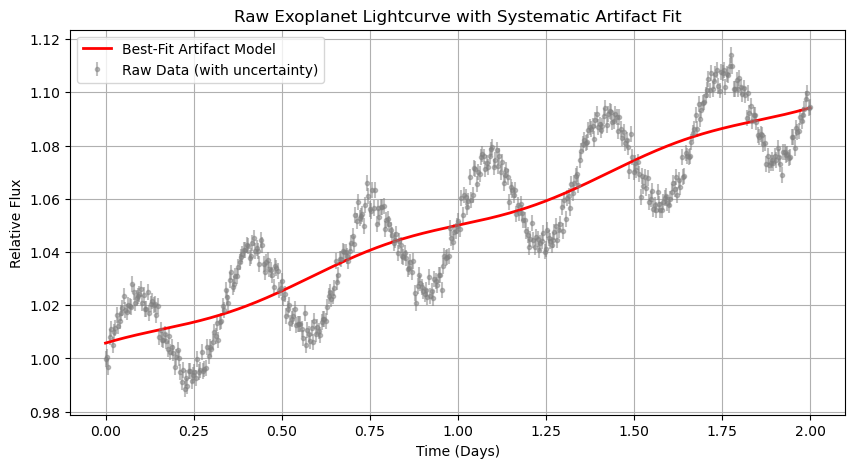

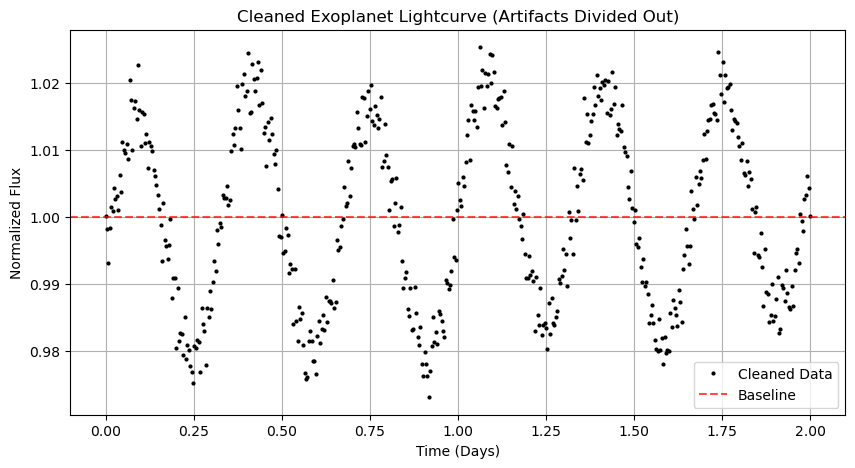

In [15]:
# Figure 1: Raw Data and Best-Fit Artifact Model
plt.figure(figsize=(10, 5))
plt.errorbar(time, flux_raw, yerr=yerr, fmt='.', color='gray', alpha=0.5, label='Raw Data (with uncertainty)')
plt.plot(time, fitted_artifacts, color='red', label='Best-Fit Artifact Model', lw=2)
plt.xlabel('Time (Days)')
plt.ylabel('Relative Flux')
plt.title('Raw Exoplanet Lightcurve with Systematic Artifact Fit')
plt.legend()
plt.grid(True)
plt.savefig('raw_data_and_fit.pdf', format='pdf')
plt.show()

# Figure 2: Cleaned Data
plt.figure(figsize=(10, 5))
plt.plot(time, flux_cleaned, '.', color='black', markersize=4, label='Cleaned Data')
plt.axhline(1.0, color='red', linestyle='--', alpha=0.7, label='Baseline')
plt.xlabel('Time (Days)')
plt.ylabel('Normalized Flux')
plt.title('Cleaned Exoplanet Lightcurve (Artifacts Divided Out)')
plt.legend()
plt.grid(True)
plt.savefig('cleaned_lightcurve.pdf', format='pdf')
plt.show()